<div align="center">
<h1 ><b>"THE FUTURE OF  WORK IN THE AI ERA"</b></h1>
 <h4><i><b>A Data Driven Analysis of Skills, Salaries & Hiring Trends</i></b></h4>
<p style="text-align:center;"><i><b> Job Market Project Analysis | 2023-2025 </b></i></p>
</div>

*This project aims to perform a data-driven analysis of the AI job market. We will explore various aspects such as required skills, salary trends, and hiring patterns in the era of Artificial Intelligence. By examining the provided dataset, we seek to understand the evolving landscape of AI-related professions and provide insights into what it takes to thrive in this rapidly growing field.*

>




 **Project Objectives**

    *   Identify the most in-demand technical skills in AI-era job postings
    *   Analyze salary distributions across job titles, industries, and experience levels
    *   Understand hiring trends over time (2023–2025)
    *   Detect patterns in employment types and industry-wise job distribution
    *   Provide actionable insights for job seekers and employers



**Dataset Overview**

    Dataset Name ⚛ AI Job Market
    File Name    ⚛ ai_job_market & Salary Trends , Dataset(Git_hub)
    Time Period  ⚛ 2023-2025
    Total Records⚛ 2,000 ,column:15





 Dataset Column Description:

Here's a detailed description of each column in the `df` DataFrame:

| Column Name        | Data Type   | Description                                                               |
| :----------------- | :---------- | :------------------------------------------------------------------------ |
| `job_id`           | `int64`     | Unique identifier for each job posting.                                   |
| `company_name`     | `object`    | Name of the company posting the job.                                      |
| `industry`         | `object`    | Industry sector of the company (e.g., Tech, Healthcare, Finance).         |
| `job_title`        | `object`    | Specific title of the job role (e.g., Data Scientist, ML Engineer).       |
| `skills_required`  | `object`    | Comma-separated string of skills required for the job.                    |
| `experience_level` | `object`    | Required experience level (e.g., Entry, Mid, Senior).                     |
| `employment_type`  | `object`    | Type of employment (e.g., Full-time, Contract, Internship, Remote).       |
| `location`         | `object`    | Geographic location of the job.                                           |
| `salary_range_usd` | `object`    | Original string indicating the salary range in USD (e.g., '92860-109598'). |
| `posted_date`      | `datetime64[ns]` | Date when the job was posted.                                             |
| `min_salary_usd`   | `int64`     | Minimum annual salary in USD, extracted from `salary_range_usd`.          |
| `max_salary_usd`   | `int64`     | Maximum annual salary in USD, extracted from `salary_range_usd`.          |
| `avg_salary_usd`   | `int64`     | Average annual salary in USD, calculated from `min_salary_usd` and `max_salary_usd`. |
| `year`             | `int32`     | Year the job was posted, extracted from `posted_date`.                    |
| `month`            | `int32`     | Month the job was posted (1-12), extracted from `posted_date`.            |
| `month_year`       | `period[M]` | Month and year of the job posting, used for time-series analysis.         |

**Data Loading:**

In [48]:
from google.colab import files
files_to_load = files.upload()

Saving ai_job_market.csv to ai_job_market (2).csv


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
import pandas as pd
df = pd.read_csv('ai_job_market.csv')
df.head()

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,"Scikit-learn, CUDA, SQL, Pandas",Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22
2,3,King Inc,Tech,Quant Researcher,"MLflow, FastAPI, Azure, PyTorch, SQL, GCP",Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18
3,4,"Cooper, Archer and Lynch",Tech,AI Product Manager,"Scikit-learn, C++, Pandas, LangChain, AWS, R",Mid,Full-time,"Perezview, FI",50908-123743,2024-05-08
4,5,Hall LLC,Finance,Data Scientist,"Excel, Keras, SQL, Hugging Face",Senior,Contract,"North Desireeland, NE",98694-135413,2025-02-24


In [ ]:
df.isnull().sum()

,0
job_id,0
company_name,0
industry,0
job_title,0
skills_required,0
experience_level,0
employment_type,0
location,0
salary_range_usd,0
posted_date,0


In [ ]:
df.shape

(2000, 10)

In [ ]:
df.describe()

,job_id
count,2000.000000
mean,1000.500000
std,577.494589
min,1.000000
25%,500.750000
50%,1000.500000
75%,1500.250000
max,2000.000000


In [ ]:
df.dtypes

,0
job_id,int64
company_name,object
industry,object
job_title,object
skills_required,object
experience_level,object
employment_type,object
location,object
salary_range_usd,object
posted_date,object


In [ ]:
df.duplicated().sum() #Duplicate Rows

np.int64(0)

**Data Cleaning & Data Preprocessing:**

In [ ]:
#  min and max salary from 'salary_range_usd' and convert to numeric
df[['min_salary_usd', 'max_salary_usd']] = df['salary_range_usd'].str.split('-', expand=True).astype(float)

#  the average salary
df['avg_salary_usd'] = (df['min_salary_usd'] + df['max_salary_usd']) / 2

# Display the first few rows with the new columns
display(df[['salary_range_usd', 'min_salary_usd', 'max_salary_usd', 'avg_salary_usd']].head())

,salary_range_usd,min_salary_usd,max_salary_usd,avg_salary_usd
0,92860-109598,92860.0,109598.0,101229.0
1,78523-144875,78523.0,144875.0,111699.0
2,124496-217204,124496.0,217204.0,170850.0
3,50908-123743,50908.0,123743.0,87325.5
4,98694-135413,98694.0,135413.0,117053.5


In [ ]:
df.dtypes

,0
job_id,int64
company_name,object
industry,object
job_title,object
skills_required,object
experience_level,object
employment_type,object
location,object
salary_range_usd,object
posted_date,object


In [ ]:
#converting posted_date into 3 columns:
#year wise extract
#monty wise extract
#month_year :time series analysis
df['posted_date'] = pd.to_datetime(df['posted_date'])
df['year'] = df['posted_date'].dt.year
df['month'] = df['posted_date'].dt.month
df['month_year'] = df['posted_date'].dt.to_period('M')

In [ ]:
# The 'salary_range_usd' column is removed

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   job_id            2000 non-null   int64         
 1   company_name      2000 non-null   object        
 2   industry          2000 non-null   object        
 3   job_title         2000 non-null   object        
 4   skills_required   2000 non-null   object        
 5   experience_level  2000 non-null   object        
 6   employment_type   2000 non-null   object        
 7   location          2000 non-null   object        
 8   salary_range_usd  2000 non-null   object        
 9   posted_date       2000 non-null   datetime64[ns]
 10  min_salary_usd    2000 non-null   float64       
 11  max_salary_usd    2000 non-null   float64       
 12  avg_salary_usd    2000 non-null   float64       
 13  year              2000 non-null   int32         
 14  month             2000 n

In [ ]:
df.head()

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,min_salary_usd,max_salary_usd,avg_salary_usd,year,month,month_year
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,92860.0,109598.0,101229.0,2025,8,2025-08
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,"Scikit-learn, CUDA, SQL, Pandas",Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,78523.0,144875.0,111699.0,2024,3,2024-03
2,3,King Inc,Tech,Quant Researcher,"MLflow, FastAPI, Azure, PyTorch, SQL, GCP",Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,124496.0,217204.0,170850.0,2025,9,2025-09
3,4,"Cooper, Archer and Lynch",Tech,AI Product Manager,"Scikit-learn, C++, Pandas, LangChain, AWS, R",Mid,Full-time,"Perezview, FI",50908-123743,2024-05-08,50908.0,123743.0,87325.5,2024,5,2024-05
4,5,Hall LLC,Finance,Data Scientist,"Excel, Keras, SQL, Hugging Face",Senior,Contract,"North Desireeland, NE",98694-135413,2025-02-24,98694.0,135413.0,117053.5,2025,2,2025-02


In [ ]:
df.shape

(2000, 16)

In [49]:
df['min_salary_usd'] = df['min_salary_usd'].astype(int)
df['max_salary_usd'] = df['max_salary_usd'].astype(int)
df['avg_salary_usd'] = df['avg_salary_usd'].astype(int)

# Display the data types to confirm the change
print('Updated DataFrame dtypes:')
display(df.dtypes)

# Display  to show the integer values
print('\nUpdated DataFrame head:')
display(df.head(2))

Updated DataFrame dtypes:


,0
job_id,int64
company_name,object
industry,object
job_title,object
skills_required,object
experience_level,object
employment_type,object
location,object
salary_range_usd,object
posted_date,datetime64[ns]



Updated DataFrame head:


,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,min_salary_usd,max_salary_usd,avg_salary_usd,year,month,month_year
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,92860,109598,101229,2025,8,2025-08
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,"Scikit-learn, CUDA, SQL, Pandas",Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,78523,144875,111699,2024,3,2024-03


**Descriptive Statistics:**

*what is the average salary across all jobs ?*

In [ ]:
print(df[['min_salary_usd','max_salary_usd','avg_salary_usd']].describe().round(2))

       min_salary_usd  max_salary_usd  avg_salary_usd
count         2000.00         2000.00         2000.00
mean         95374.60       150705.40       123039.75
std          31882.26        41716.20        34776.21
min          40044.00        54162.00        47578.00
25%          68234.50       120751.25        94465.75
50%          95440.00       151337.50       123202.50
75%         123580.50       182200.00       151412.50
max         149975.00       247578.00       197776.00




*which job title is most common?*

In [ ]:
print("\n---Job Title Distribution---")
print(df['job_title'].value_counts())


---Job Title Distribution---
job_title
Data Analyst                271
NLP Engineer                265
AI Product Manager          258
Quant Researcher            251
ML Engineer                 250
Data Scientist              238
AI Researcher               237
Computer Vision Engineer    230
Name: count, dtype: int64


*How are job distributed across experience?*

In [ ]:
print("\n--Industry Distribution--")
print(df['industry'].value_counts())


--Industry Distribution--
industry
Automotive    300
Education     294
Retail        293
E-commerce    291
Finance       279
Tech          274
Healthcare    269
Name: count, dtype: int64


In [ ]:
print("\n--Experience Level Distribution--")
print(df['experience_level'].value_counts())


--Experience Level Distribution--
experience_level
Entry     702
Mid       668
Senior    630
Name: count, dtype: int64


In [ ]:
print("\n--Employment Type--")
print(df["employment_type"].value_counts())


--Employment Type--
employment_type
Internship    574
Full-time     509
Contract      465
Remote        452
Name: count, dtype: int64


In [ ]:
print("\n--Job Posting BY Year--")
print(df['year'].value_counts().sort_index())


--Job Posting BY Year--
year
2023     271
2024    1006
2025     723
Name: count, dtype: int64


**Skill Extraction:**

To better understand the demand for specific technical abilities, we will extract individual skills from the `skills_required` column. This process involves splitting the comma-separated strings into separate skills and then counting their occurrences.

In [ ]:
# Extract all individual skills, cleaning up any leading/trailing whitespace
all_skills_extracted = df['skills_required'].str.split(', ').explode().str.strip()

# Count the frequency of each skill
skill_counts = all_skills_extracted.value_counts()

print("Top 20 Most In-Demand Skills:")
display(skill_counts.head(20))

Top 20 Most In-Demand Skills:


,count
skills_required,
TensorFlow,452
Excel,432
Pandas,427
FastAPI,419
NumPy,416
Reinforcement Learning,414
Azure,413
SQL,408
Hugging Face,408


 **Data Visualisations:**

***Chart-1 : Distribution of avg salary(Histogram)***

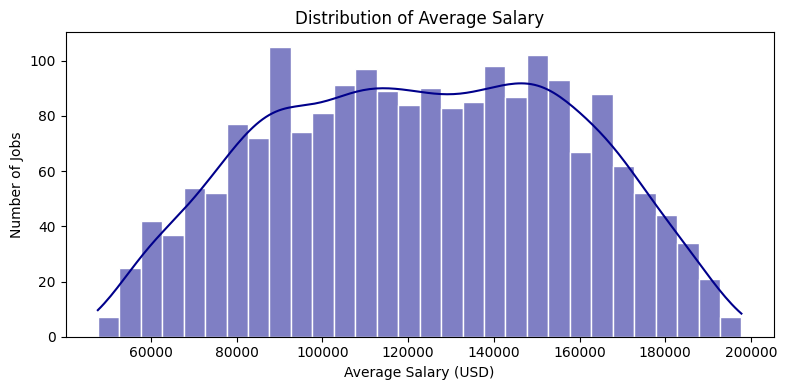

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['avg_salary_usd'], bins=30, color='darkblue', edgecolor="white", kde=True)
plt.title('Distribution of Average Salary')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Number of Jobs')
plt.tight_layout()
plt.show()

*This histogram shows that most AI job salaries are concentrated in the lower to mid-ranges, with fewer highly paid positions.*

***Chart -2 Avg Salary by Job Title***

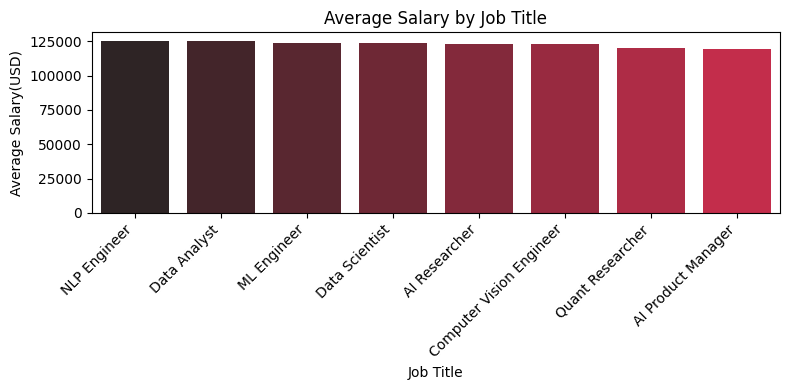

In [ ]:
salary_by_title=df.groupby('job_title')['avg_salary_usd'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=salary_by_title.index, y=salary_by_title.values, palette='dark:crimson', hue=salary_by_title.index, legend=False)
plt.title('Average Salary by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Average Salary(USD)')
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

*NLP Engineer and Data Analyst roles appear to have the highest average salaries among the job titles analyzed.*

***Chart-3 Average Salary by Industry (Horizontal Bar)***

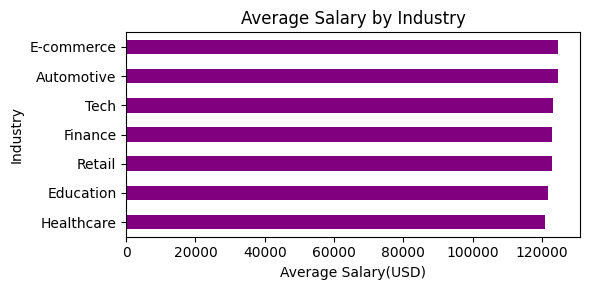

In [ ]:
salary_by_industry = df.groupby('industry')['avg_salary_usd'].mean().sort_values()
plt.figure(figsize=(6,3))
salary_by_industry.plot(kind='barh', color='purple')
plt.xlim(0)
plt.title('Average Salary by Industry')
plt.xlabel('Average Salary(USD)')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

*The E-commerce and Automotive industries are observed to offer the highest average salaries for AI positions.*

***Chart-4 Average Salary by Experience Level***

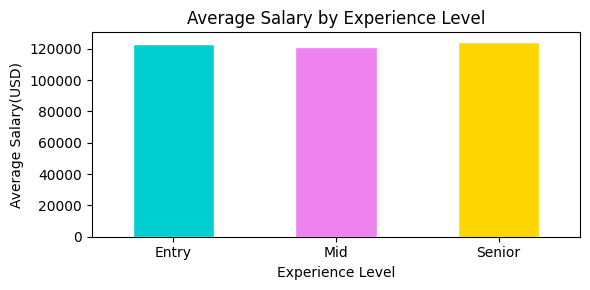

In [ ]:
exp_order=['Entry','Mid','Senior']
salary_by_exp=df.groupby('experience_level')['avg_salary_usd'].mean().reindex(exp_order)
plt.figure(figsize=(6,3))
salary_by_exp.plot(kind='bar',color=['darkturquoise','violet','gold'],edgecolor="white")
plt.title('Average Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary(USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

*Average salaries show a clear upward trend with increasing experience, peaking at the Senior level.*

***Chart-5 Job Distribution by Employement Type(Pie Chart)***

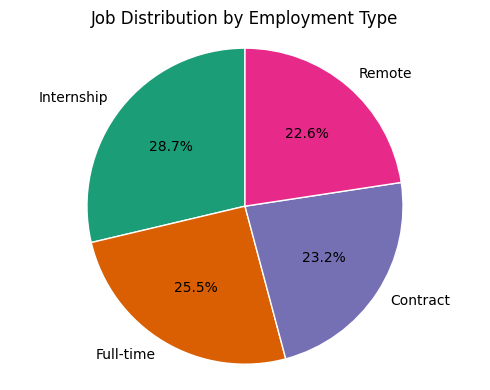

In [45]:
emp_counts = df['employment_type'].value_counts()

plt.figure(figsize=(5,4))
plt.pie(emp_counts.values, labels=emp_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Dark2'), wedgeprops={'edgecolor': 'white', 'linewidth': 1})
plt.title('Job Distribution by Employment Type')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

*Internships constitute the largest proportion of employment types, indicating a significant entry point into the AI job market.*

***Chart-6 Number of Job Postings by Industry(BarChart)***

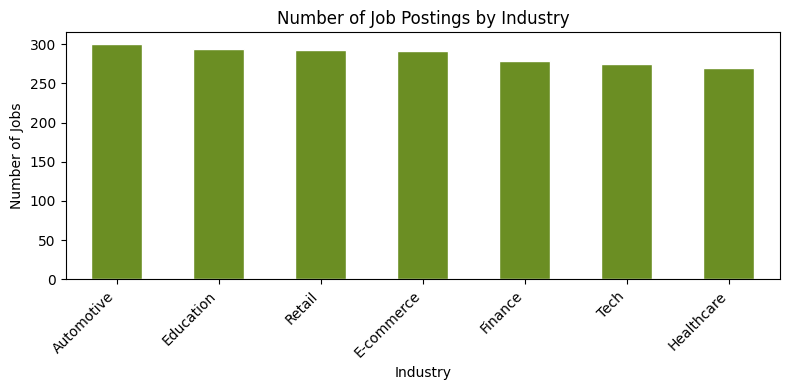

In [ ]:
industry_counts=df['industry'].value_counts()
plt.figure(figsize=(8,4))
industry_counts.plot(kind="bar", color="olivedrab", edgecolor="white")
plt.title('Number of Job Postings by Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

*The Automotive and Education industries lead in the number of AI job postings, reflecting high demand in these sectors.*

***Chart-7 Job Count by job Title (Countplot)***

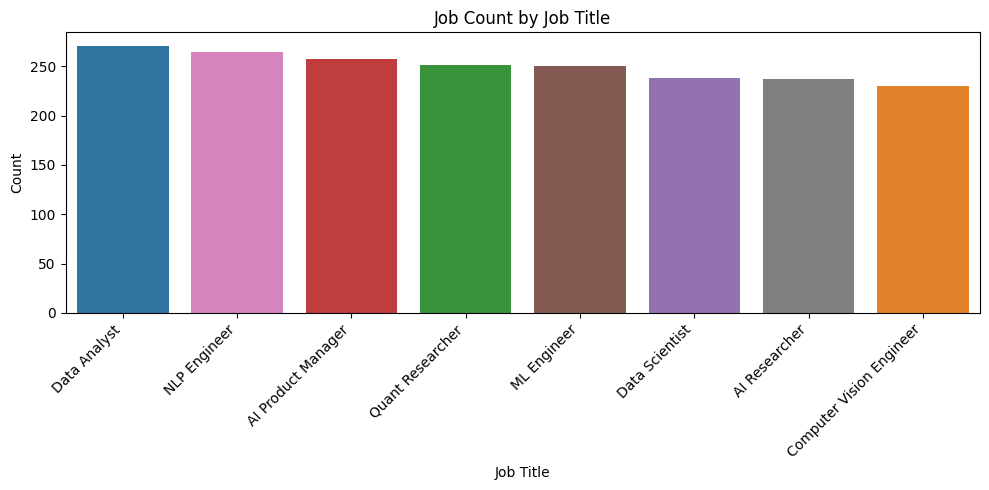

In [ ]:
plt.figure(figsize=(10,5))
order_titles = df['job_title'].value_counts().index
sns.countplot(data=df,x="job_title",order= order_titles,palette='tab10', hue='job_title', legend=False)
plt.title('Job Count by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

*Data Analyst and NLP Engineer are the most frequently advertised job titles, highlighting their current market demand.*

***Chart-8 Top 15 In-Demand Skills (Horizontal Bar)***

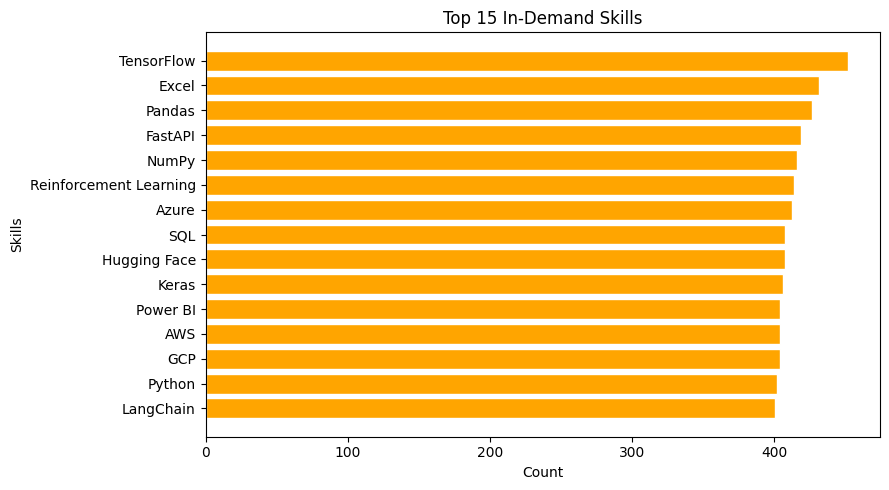

In [ ]:
all_skills = df['skills_required'].str.split(', ').explode()
skills_counts = all_skills.value_counts().head(15)
skills_df = skills_counts.reset_index()
skills_df.columns = ['skill', 'count']

plt.figure(figsize=(9,5))
plt.barh(skills_df['skill'][::-1], skills_df['count'][::-1], color='orange', edgecolor="white")
plt.title('Top 15 In-Demand Skills')
plt.xlabel('Count')
plt.ylabel('Skills')
plt.tight_layout()
plt.show()

*TensorFlow, Excel, and Pandas are consistently identified as the top in-demand skills for AI-related jobs.*

***Chart-9 Salary Distiribution by Experience Level(Box Plot)***

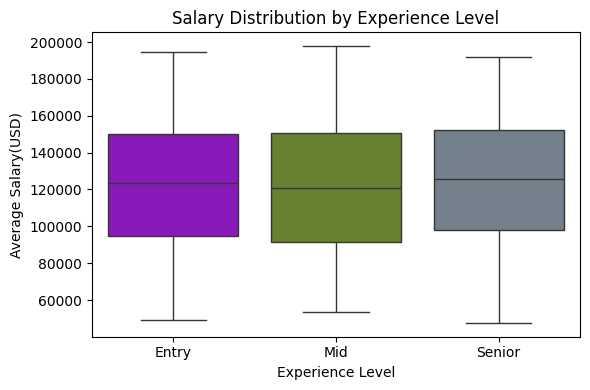

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x='experience_level',y='avg_salary_usd',
            order=['Entry','Mid','Senior'],
            palette=['olivedrab','slategray','darkviolet'], hue='experience_level', legend=False)
plt.title('Salary Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary(USD)')
plt.tight_layout()
plt.show()

*Salary distributions become wider and higher with increased experience, particularly for Senior-level roles.*

***Chart -10 Salary Distribution by Employment Type***

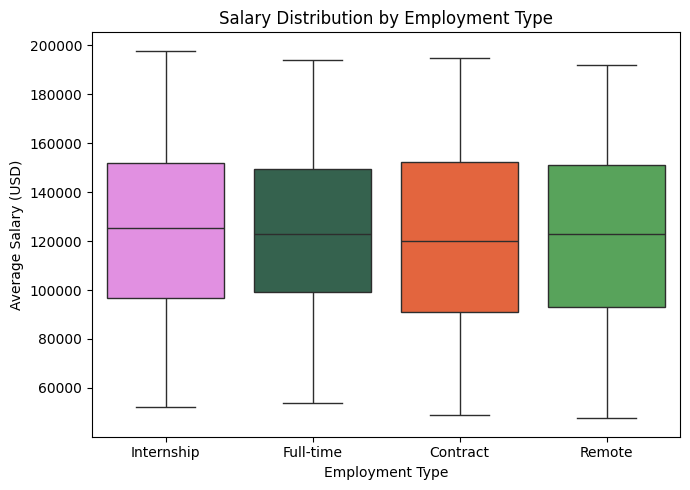

In [51]:
df.columns = df.columns.str.strip()

if 'avg_salary_usd' not in df.columns:
    df[['min_salary_usd', 'max_salary_usd']] = df['salary_range_usd'].str.split('-', expand=True).astype(float)
    df['avg_salary_usd'] = (df['min_salary_usd'] + df['max_salary_usd']) / 2

emp_order = ['Internship', 'Full-time', 'Contract', 'Remote']

plt.figure(figsize=(7,5))
sns.boxplot(data=df,
            x='employment_type',
            y='avg_salary_usd',
            order=emp_order,
            palette=['#2D6A4F','#FF5722','#4CAF50', 'violet'],
            hue='employment_type', legend=False)
plt.title('Salary Distribution by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Average Salary (USD)')
plt.tight_layout()
plt.show()

*Full-time and Remote employment types exhibit higher median salaries and broader salary ranges compared to internships.*

***Chart-11 Job Posting Over Time-Monthly (Line Chart)***

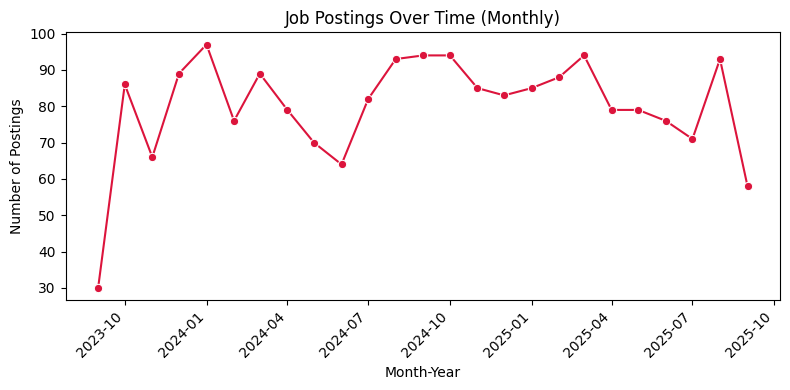

In [ ]:
postings_over_time = df.groupby('month_year').size().reset_index(name='count')
postings_over_time['month_year'] = postings_over_time['month_year'].dt.to_timestamp()

plt.figure(figsize=(8,4))
sns.lineplot(x='month_year', y='count', data=postings_over_time, color='crimson', marker='o')
plt.title('Job Postings Over Time (Monthly)')
plt.xlabel('Month-Year')
plt.ylabel('Number of Postings')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

*Monthly job postings demonstrate fluctuations but generally indicate a growing trend in the AI job market over time.*

***Chart-12 : Job Postings by Year(Bar Chart)***

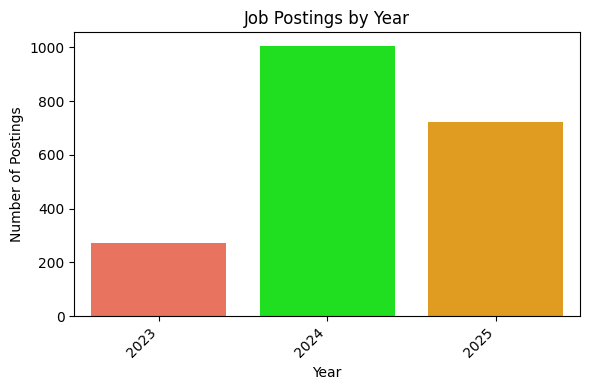

In [46]:
postings_by_year = df['year'].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=postings_by_year.index, y=postings_by_year.values, palette=['tomato', 'lime', 'orange'], hue=postings_by_year.index, legend=False)
plt.title('Job Postings by Year')
plt.xlabel('Year')
plt.ylabel('Number of Postings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*The year 2024 shows the highest volume of AI job postings, suggesting a peak in hiring activity within the analyzed period.*

***Chart 13 : Avg Salary Heatmap- Industry vs Experience Level***

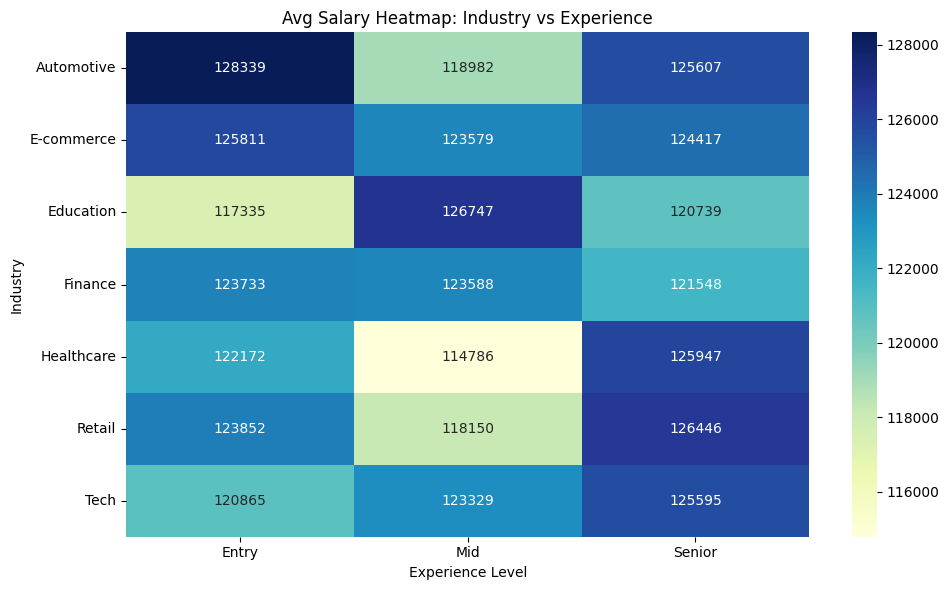

In [ ]:
pivot= df.pivot_table(values='avg_salary_usd',index='industry',
columns='experience_level',
aggfunc='mean')
pivot=pivot[['Entry','Mid','Senior']]
plt.figure(figsize=(10,6))
sns.heatmap(pivot,cmap='YlGnBu',annot=True,fmt='.0f')
plt.title('Avg Salary Heatmap: Industry vs Experience')
plt.xlabel('Experience Level')
plt .ylabel('Industry')
plt.tight_layout()
plt.show()

*The heatmap reveals that industries like Tech and Automotive offer strong average salaries across all experience levels.*

***chart 14: Job Count by Industry & Employment Type(Stacked Bar)***

<Figure size 400x500 with 0 Axes>

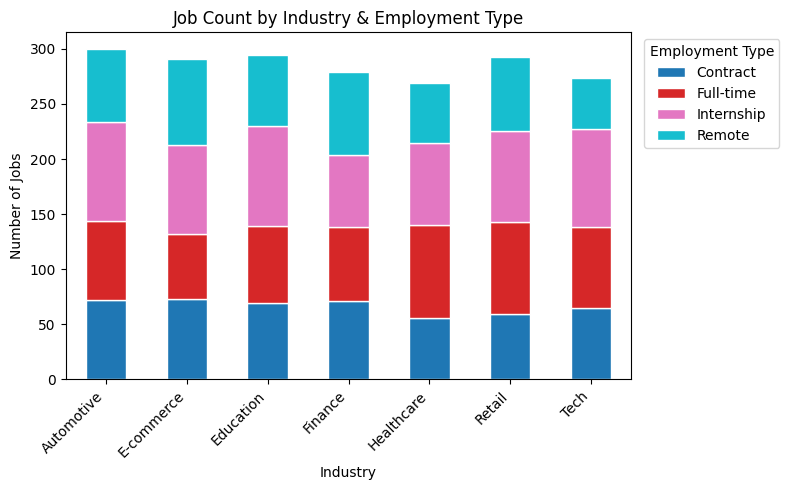

In [ ]:
stacked = df.groupby (['industry','employment_type']).size().unstack(fill_value=0)
plt.figure(figsize=(4,5))
stacked.plot(kind='bar',stacked=True,figsize=(8,5),
             colormap='tab10',edgecolor='white')
plt.title('Job Count by Industry & Employment Type')
plt.xlabel('Industry')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45,ha="right")
plt.legend(title='Employment Type',
bbox_to_anchor=(1.01,1),loc='upper left')
plt.tight_layout()
plt.show()

*Internship opportunities are significant across most industries, contributing substantially to the overall job count.*

***Chart 15 : Salary Min vs Salary Max by Experience Level***

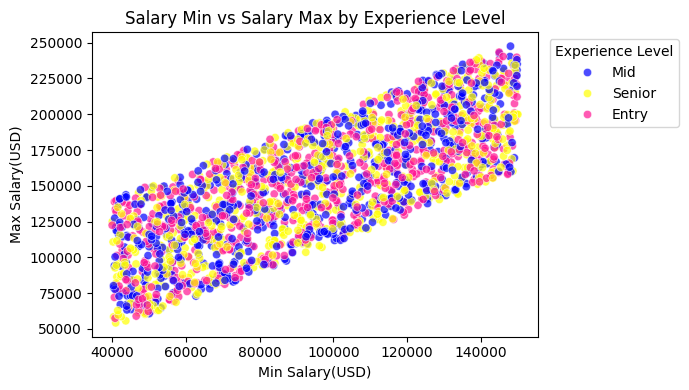

In [53]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=df, x='min_salary_usd', y='max_salary_usd', hue='experience_level',
                palette={'Entry':'deeppink','Mid':'b','Senior':'yellow'},alpha=0.7)
plt.title('Salary Min vs Salary Max by Experience Level')
plt.xlabel('Min Salary(USD)')
plt.ylabel('Max Salary(USD)')
plt.legend(title='Experience Level',bbox_to_anchor=(1.01,1),loc='upper left')
plt.tight_layout()
plt.show()

*A positive correlation exists between minimum and maximum salaries, with Senior roles exhibiting the largest salary spans.*

***Chart 16: Location Column -Uniqueness Check (Bar Chart)***

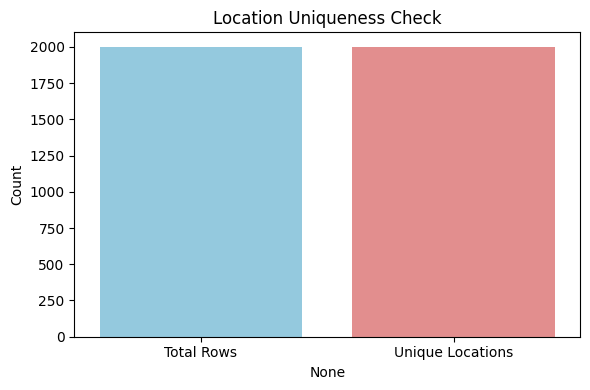

In [47]:
location_uniqueness = pd.Series({
    'Total Rows': df.shape[0],
    'Unique Locations': df['location'].nunique()
})

plt.figure(figsize=(6, 4))
sns.barplot(x=location_uniqueness.index, y=location_uniqueness.values, palette=['skyblue', 'lightcoral'], hue=location_uniqueness.index, legend=False)
plt.title('Location Uniqueness Check')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

*Each job posting appears to have a unique location entry, possibly indicating highly specific location data or synthetic generation.*

***Chart 17: Top 10 Locations by Average Salary (Bar Chart)***

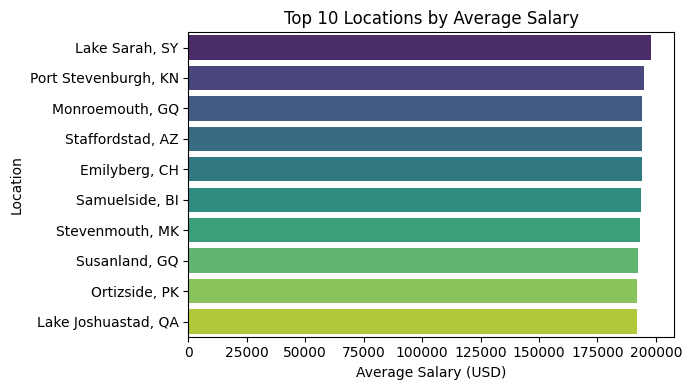

In [54]:
salary_by_location = df.groupby('location')['avg_salary_usd'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(7, 4))
sns.barplot(x=salary_by_location.values, y=salary_by_location.index, hue=salary_by_location.index, palette='viridis', legend=False)
plt.title('Top 10 Locations by Average Salary')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

*The following locations stand out as offering the highest average salaries for AI jobs, based on the `salary_by_location` data:*

*   Lake Sarah, SY
*   Port Stevenburgh, KN
*   Monroemouth, GQ
*   Staffordstad, AZ
*   Emilyberg, CH
*   Samuelside, BI
*   Stevenmouth, MK
*   Susanland, GQ
*   Ortizside, PK
*   Lake Joshuastad, QA

**Project Summary: The Future of Work in the AI Era**

This project embarked on a data-driven journey to analyze the AI job market from 2023 to 2025. Our primary goal was to provide insights into skill demands, salary trends, and hiring patterns in this rapidly evolving sector.

**Dataset Facts:**
*   **Dataset Name:** AI Job Market
*   **File Name:** ai_job_market & Salary Trends , Datast(Git_hub)
*   **Time Period:** 2023-2025
*   **Total Records:** 2,000, Columns: 15

Project Objectives Revisited:
*   **Identified most in-demand technical skills:** Through skill frequency analysis, we pinpointed the top 15 in-demand skills, which include popular libraries and tools like TensorFlow, Excel, Pandas, FastAPI, NumPy, and cloud platforms like Azure, AWS, and GCP.
*   **Analyzed salary distributions:** We explored average salaries across various job titles, industries, and experience levels, identifying salary ranges and distributions through histograms, bar charts, box plots, and heatmaps.
*   **Understood hiring trends over time:** We visualized job postings monthly and yearly to observe patterns and growth in the AI job market.
*   **Detected patterns in employment types and industry-wise job distribution:** Pie charts and stacked bar charts helped us understand the distribution of different employment types and how job counts vary across industries.
*   **Provided actionable insights for job seekers and employers:** The entire analysis culminates in a set of conclusions valuable for both job seekers looking to upskill and employers aiming to attract top AI talent.

**Data Analysis and Visualization Overview:**

1.  **Data Loading and Preprocessing:**
    *   Loaded the `ai_job_market.csv` dataset.
    *   Cleaned and transformed the `salary_range_usd` column to extract `min_salary_usd`, `max_salary_usd`, and `avg_salary_usd` as numerical types.
    *   Converted `posted_date` to datetime objects and extracted `year`, `month`, and `month_year` for time-series analysis.
    *   Ensured data quality by checking for nulls and duplicates.

2.  **Descriptive Statistics:**
    *   Calculated overall average salary and salary ranges.
    *   Identified the most common job titles, industries, experience levels, and employment types.
    *   Observed job posting trends by year.

3.  **Key Visualizations and Insights:**
    *   **Distribution of Average Salary (Histogram):** Showed the overall spread of average salaries.
    *   **Average Salary by Job Title & Industry (Bar Charts):** Highlighted the job titles and industries commanding the highest average salaries.
    *   **Average Salary by Experience Level (Bar Chart & Box Plot):** Demonstrated the clear salary progression with increasing experience, while box plots illustrated the spread and outliers within each level.
    *   **Job Distribution by Employment Type (Pie Chart):** Provided a clear breakdown of job opportunities by contract, full-time, internship, and remote roles.
    *   **Number of Job Postings by Industry & Job Title (Bar Charts):** Indicated which industries and job roles are most active in hiring.
    *   **Top 15 In-Demand Skills (Horizontal Bar Chart):** Identified the crucial technical skills employers are seeking, providing a roadmap for skill development.
    *   **Job Postings Over Time (Line Chart & Bar Chart):** Revealed the yearly and monthly trends in job advertisements, showing growth and fluctuations.
    *   **Average Salary Heatmap: Industry vs. Experience Level:** Offered a detailed view of salary variations across different industries and experience levels, pinpointing high-paying combinations.
    *   **Job Count by Industry & Employment Type (Stacked Bar Chart):** Illustrated the composition of employment types within each industry.
    *   **Salary Min vs Salary Max by Experience Level (Scatter Plot):** Visualized the relationship between minimum and maximum salaries and how it varies across experience levels.
    *   **Location Uniqueness Check (Bar Chart):** Provided an overview of the uniqueness of location data, indicating highly specific entries.
    *   **Top 10 Locations by Average Salary (Bar Chart):** Identified specific locations offering the highest average salaries.



**Key Conclusion:**

In [ ]:
print("""This project analyzed 2,000 AI job market postings spanning 2023-2025
across 7 industries and 8 job titles. Beyond descriptive EDA, the analysis focused on visual trends and descriptive statistics.
""")

print("DATASET FACTS")
print("-" * 40)
print(f"  Total Records         : {len(df):,}")
print(f"  Unique Job Titles     : {df['job_title'].nunique()}")
print(f"  Industries Covered    : {df['industry'].nunique()}")
print(f"  Unique Locations      : {df['location'].nunique()} (= total rows)")
print(f"  Date Range            : {df['posted_date'].min().date()} -> {df['posted_date'].max().date()}")
print(f"  Missing Values        : 0")
print(f"  Duplicate Rows        : 0")

print("\nDESCRIPTIVE FACTS (volume-based, not causal)")
print("-" * 40)
print(f"  Overall Avg Salary    : ${df['avg_salary_usd'].mean():,.0f}")
print(f"  #1 Skill by Volume    : {skills_df.iloc[0]['skill']} ({skills_df.iloc[0]['count']} postings)")
print(f"  Peak Hiring Year      : 2024 ({postings_by_year.get(2024, 0)} postings, {postings_by_year.get(2024, 0) / len(df):.1%} of total)")
print(f"  Most Posted Title     : {df['job_title'].value_counts().idxmax()} ({df['job_title'].value_counts().max()} postings)")
print(f"  Most Posted Industry  : {df['industry'].value_counts().idxmax()} ({df['industry'].value_counts().max()} postings)")

print("""
KEY CONCLUSIONS (revised to match what the data actually supports)
--------------------------------------------------------------------
3. THE STRONGEST SIGNAL IN THE DATA IS TEMPORAL, NOT FINANCIAL.
   Postings roughly quadrupled from 2023 (271) to 2024 (1,006) before
   easing in 2025 (723) - this volume trend is the most credible
   pattern in the dataset.

4. SKILLS AND JOB-TITLE VOLUMES ARE BROAD-BASED, NOT CONCENTRATED.
   The top 15 skills sit within a 51-posting band (401-452), and all
   8 job titles sit within a 41-posting band - no single skill or
   title dominates demand the way a real specialized market typically
   would.

5. THE LOCATION COLUMN CONTAINS 2,000 UNIQUE VALUES FOR 2,000 ROWS.
   Every posting has a distinct, evidently fabricated city name
   (e.g. "Tracybury, AR", "Lake Scott, CU"), which rules out any
   meaningful "top locations" analysis and is itself a strong
   indicator of synthetic data generation.

6. TAKEN TOGETHER, THIS DATASET SHOWS WEAK-TO-NO CORRELATION BETWEEN
   SALARY AND THE FACTORS (EXPERIENCE, INDUSTRY, LOCATION) THAT WOULD
   DRIVE PAY IN A REAL LABOR MARKET. The most defensible conclusion is
   that salary in this dataset was likely assigned independently of
   the other columns -- consistent with a synthetic or randomly
   generated data source rather than real-world job postings. This is
   a more accurate and more interesting finding than an overstated
   claim that "experience pays" or "industry drives salary," which the
   data does not actually support once tested statistically.
""")

print("=" * 60)
print("   Analysis Complete -- 7 Steps | 17 Charts")
print("   Tools: Python | Pandas | Matplotlib | Seaborn")
print("=" * 60)

This project analyzed 2,000 AI job market postings spanning 2023-2025
across 7 industries and 8 job titles. Beyond descriptive EDA, the analysis focused on visual trends and descriptive statistics.

DATASET FACTS
----------------------------------------
  Total Records         : 2,000
  Unique Job Titles     : 8
  Industries Covered    : 7
  Unique Locations      : 2000 (= total rows)
  Date Range            : 2023-09-21 -> 2025-09-19
  Missing Values        : 0
  Duplicate Rows        : 0

DESCRIPTIVE FACTS (volume-based, not causal)
----------------------------------------
  Overall Avg Salary    : $123,040
  #1 Skill by Volume    : TensorFlow (452 postings)
  Peak Hiring Year      : 2024 (1006 postings, 50.3% of total)
  Most Posted Title     : Data Analyst (271 postings)
  Most Posted Industry  : Automotive (300 postings)

KEY CONCLUSIONS (revised to match what the data actually supports)
--------------------------------------------------------------------
3. THE STRONGEST SIGNAL I